In [1]:
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"

In [2]:

import numpy as np
import os
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, Normalize
import time
import pickle

from concurrent.futures import ProcessPoolExecutor, as_completed

import discretize
# from simpeg import dask
from simpeg import (
    maps,
    Data,
    data_misfit,
    inverse_problem,
    regularization,
    optimization,
    directives,
    inversion,
    utils,
)
from simpeg.electromagnetics import time_domain as tdem
from simpeg.utils.solver_utils import get_default_solver

from simpeg.meta import MultiprocessingMetaSimulation, MetaSimulation

from parametric_ellipsoid import ParametricEllipsoid

Solver = get_default_solver()



In [ ]:
rho_back = 1000
sigma_back = 1./rho_back

rho_target = 0.1
sigma_target = 1./rho_target

rho_overburden = 1000  #50
sigma_overburden = 1./rho_overburden

sigma_air = 1e-8

target_dips = np.r_[115] #, 45]
target_z = np.r_[-300, -120]

In [4]:
# rx_locs = np.loadtxt(f"{directory}/rx_locs.txt")
# rx_locs[:, 1] =
tx_height = 30

rx_x = (np.linspace(-500, 500, 26))[::2]
rx_y = (np.linspace(-400, 400, 5))[1:-1]
# rx_y = np.r_[-80, -40, 0, 40, 80]

rx_z = tx_height

rx_locs = discretize.utils.ndgrid([rx_x, rx_y, rx_z])
rx_x

# rx_times = np.loadtxt(f"{directory}/rx_times.txt")
rx_times = np.logspace(np.log10(2e-5), np.log10(2e-3), 20)

In [5]:
rx_x

array([-500., -420., -340., -260., -180., -100.,  -20.,   60.,  140.,
        220.,  300.,  380.,  460.])

In [6]:
rx_y

array([-200.,    0.,  200.])

In [7]:
def diffusion_distance(sigma, t):
    return 1260*np.sqrt(t/sigma)

In [8]:
diffusion_distance(sigma_target, 8e-3)

np.float64(35.638181771801996)

In [9]:
diffusion_distance(sigma_back, 8e-3)

np.float64(3563.8181771801997)

In [10]:
base_cell_width = 20
domain_extent = 8000

n_base_cells = 2 ** int(
    np.ceil(np.log(domain_extent / base_cell_width) / np.log(2.0))
)  # needs to be powers of 2 for the tree mesh

h = [(base_cell_width, n_base_cells)]
mesh = discretize.TreeMesh([h, h, h], origin="CCC", diagonal_balance=True)

# refine near transmitters and receivers
mesh.refine_points(
    rx_locs, level=-1, padding_cells_by_level=[2, 2, 2],
    finalize=False, diagonal_balance=True
)

# Refine core region of the mesh

bounding_points = np.array([
    [-500, rx_y.min(), target_z.min() - base_cell_width * 4],
    [500, rx_y.max(), 0],
])
mesh.refine_bounding_box(
    bounding_points, level=-1,
    diagonal_balance=True, finalize=False, padding_cells_by_level=[2, 2, 2]
)

mesh.finalize()

In [11]:
mesh

OcTreeMesh: 0.04% filled

Level : Number of cells               Mesh Extent               Cell Widths    
-----------------------           min     ,     max            min   ,   max   
  3   :       448            ---------------------------   --------------------
  4   :       448         x:    -5120.0   ,   5120.0          20.0   ,   1280.0  
  5   :       332         y:    -5120.0   ,   5120.0          20.0   ,   1280.0  
  6   :       880         z:    -5120.0   ,   5120.0          20.0   ,   1280.0  
  7   :      3040      
  8   :      6424      
  9   :      40768     
-----------------------
Total :      52340

In [12]:
def dipping_target_indices(
    mesh, target_x_center, target_z_center, dip, target_thickness, target_xlim=None, target_ylim=None, target_zlim=None
):
    """
    add a dipping target to the model. For now assumes the target dips in the x-direction
    """
    slope = np.tan(-dip*np.pi/180)
    target_z = target_z_center + target_thickness / 2 * np.r_[-1, 1]

    z_bottom = (mesh.cell_centers[:, 0] - target_x_center) * slope + target_z.min()
    z_top = (mesh.cell_centers[:, 0] - target_x_center) * slope + target_z.max()

    indices = (
        (mesh.cell_centers[:, 2] >= z_bottom) &
        (mesh.cell_centers[:, 2] <= z_top)
    )

    if target_xlim is not None:
        indices = indices & (
            (mesh.cell_centers[:, 0] >= target_xlim.min()) &
            (mesh.cell_centers[:, 0] <= target_xlim.max())
        )
    if target_ylim is not None:
        indices = indices & (
            (mesh.cell_centers[:, 1] >= target_ylim.min()) &
            (mesh.cell_centers[:, 1] <= target_ylim.max())
        )
    if target_zlim is not None:
        indices = indices & (
            (mesh.cell_centers[:, 2] >= target_zlim.min()) &
            (mesh.cell_centers[:, 2] <= target_zlim.max())
        )
    return indices

In [13]:
models = {}

target_x = np.r_[-300, 300]
target_y = np.r_[-100, 100]
target_thickness = 200

overburden_x = np.r_[-640, 640]
overburden_y = np.r_[-640, 640]
overburden_thickness = 40

# background model
background = np.ones(mesh.n_cells) * sigma_air
background[mesh.cell_centers[:, 2] < 0] = sigma_back
models["background"] = background

for dip in target_dips:
    conductivity_model = background.copy()
    indices = dipping_target_indices(
        mesh, target_x_center=0, target_z_center=np.mean(target_z),
        target_thickness=target_thickness, dip=dip,
        target_xlim=target_x,
        target_ylim=target_y,
        target_zlim=target_z
    )
    conductivity_model[indices] = sigma_target

    # add overburden
    overburden_indices = (
        (mesh.cell_centers[:, 0] >= overburden_x[0]) &
        (mesh.cell_centers[:, 0] < overburden_x[1]) &
        (mesh.cell_centers[:, 1] >= overburden_y[0]) &
        (mesh.cell_centers[:, 1] < overburden_y[1]) &
        (mesh.cell_centers[:, 2] >= -overburden_thickness) &
        (mesh.cell_centers[:, 2] < 0)
    )
    conductivity_model[overburden_indices] = sigma_overburden
    models[f"target_{dip}"] = conductivity_model



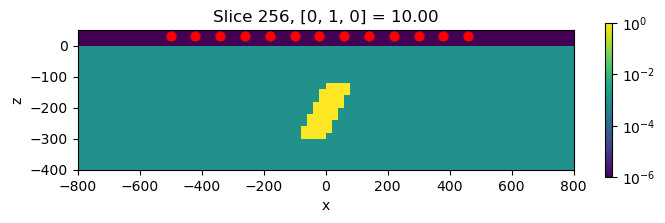

In [14]:
fig, ax = plt.subplots(1, 1, figsize=(8, 2))

plt.colorbar(
    mesh.plot_slice(
        conductivity_model,
        # grid=True,
        normal="y",
        pcolor_opts={"norm":LogNorm(1e-6, 1e0)},
        ax=ax)[0],
    ax=ax
)

ax.set_xlim(800*np.r_[-1, 1])
ax.set_ylim(np.r_[-400, 50])

ax.plot(rx_locs[:, 0], rx_locs[:, 2], "ro")
ax.set_aspect(1)

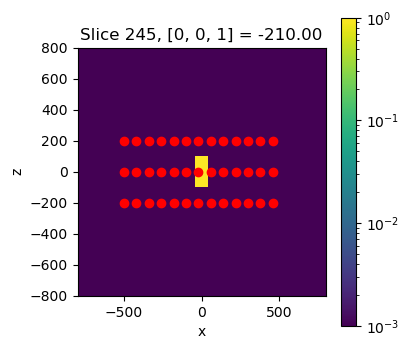

In [15]:
fig, ax = plt.subplots(1, 1, figsize=(4, 4))

# mesh_local = mesh_list[-1]

plt.colorbar(
    mesh.plot_slice(
        conductivity_model,
        # grid=True,
        normal="z",
        pcolor_opts={"norm":LogNorm(1e-3, 1e0)},
        ax=ax,
        ind=245
    )[0],
    ax=ax
)

xlim = 800*np.r_[-1, 1]
ax.set_xlim(xlim)
ax.set_ylim(xlim)

ax.plot(rx_locs[:, 0], rx_locs[:, 1], "ro")
ax.set_aspect(1)


In [16]:
source_list = []

for i in range(rx_locs.shape[0]):
    rx = tdem.receivers.PointMagneticFluxTimeDerivative(rx_locs[i, :], rx_times, orientation="z")
    src = tdem.sources.CircularLoop(
        receiver_list=[rx], location=rx_locs[i, :], orientation="z", radius=10,
        waveform=tdem.sources.StepOffWaveform()
    )
    source_list.append(src)

survey = tdem.Survey(source_list)

In [17]:
# set up local meshes
global_mesh = mesh
active_cells_map = maps.InjectActiveCells(global_mesh, global_mesh.cell_centers[:, 2]<0, value_inactive=np.log(1e-8))

refine_depth = 300
# def get_local_mesh(src):
mesh_list = []
x1 = np.mean(rx_locs[:, 0]) - (np.sum(global_mesh.h[0]) / 2)
x2 = np.mean(rx_locs[:, 1]) - (np.sum(global_mesh.h[1]) / 2)
x3 = np.mean(rx_locs[:, 2]) - (np.sum(global_mesh.h[2]) / 2)

for src in survey.source_list:
# src = survey.source_list[0]
    mesh_local = discretize.TreeMesh(global_mesh.h, origin=global_mesh.origin, diagonal_balance=True)
    refine_points = discretize.utils.ndgrid(
        np.r_[src.location[0]],
        np.r_[src.location[1]],
        np.linspace(-refine_depth, src.location[2], 40)
    )
    mesh_local.refine_points(
        refine_points,
        level=-1,
        padding_cells_by_level=[2, 2, 2],
        finalize=True,
        diagonal_balance=True
    )
    mesh_list.append(mesh_local)

    mesh_local.x0

In [18]:
mesh_local

OcTreeMesh,0.00% filled
Level,Number of cells
2,28
3,252
4,252
5,243
6,268
7,645
8,662
9,528
Total,2878


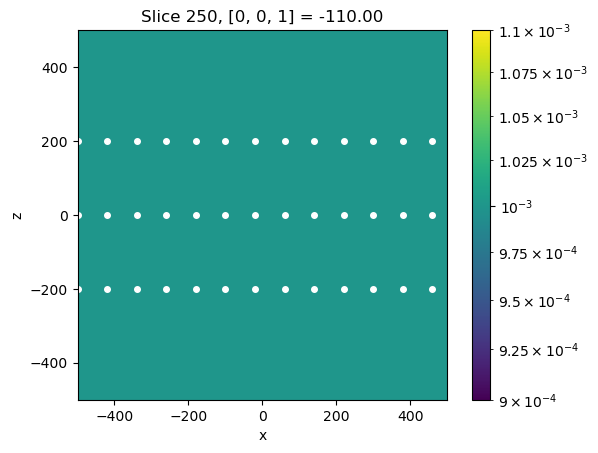

In [19]:
fig, ax = plt.subplots(1, 1)
plt.colorbar(
    mesh.plot_slice(
        models["target_115"], ax=ax, pcolor_opts={"norm":LogNorm()},
        normal="Z", ind=250
    )[0],
    ax=ax
)

ax.set_xlim(500*np.r_[-1, 1])
ax.set_ylim(500*np.r_[-1, 1])

ax.plot(rx_locs[:, 0], rx_locs[:, 1], "wo", ms=4)
ax.set_aspect(1)

In [20]:
nsteps = 20
time_steps = [
    # (1e-6, nsteps),
    # (3e-6, nsteps),
    (1e-5, nsteps),
    (3e-5, nsteps),
    (1e-4, 20),
]


mappings = []
sims = []

for ii, local_mesh in enumerate(mesh_list):

    tile_map = maps.TileMap(global_mesh, active_cells_map.active_cells, local_mesh)
    mappings.append(tile_map)

    local_actmap = maps.InjectActiveCells(
        local_mesh,
        active_cells=tile_map.local_active,
        value_inactive=np.log(1e-8)
    )

    local_survey = tdem.Survey([survey.source_list[ii]])
    sims.append(tdem.simulation.Simulation3DElectricField(
            mesh=local_mesh,
            survey=local_survey,
            time_steps=time_steps,
            solver=Solver,
            sigmaMap=maps.ExpMap() * local_actmap
        )
    )


sim = MultiprocessingMetaSimulation(sims, mappings)

/home/lheagy/git/simpeg/simpeg/simpeg/meta/multiprocessing.py:229: UserWarning: The MetaSimulation class is a work in progress and might change in the future
  super().__init__(simulations, mappings)
/home/lheagy/git/simpeg/simpeg/simpeg/meta/multiprocessing.py:248: UserWarning: The MetaSimulation class is a work in progress and might change in the future
  sim_chunk = MetaSimulation(


/home/lheagy/miniforge3/envs/py311/lib/python3.11/site-packages/pymatsolver/solvers.py:415: FutureWarning: In Future pymatsolver v0.4.0, passing a vector of shape (n, 1) to the solve method will return an array with shape (n, 1), instead of always returning a flattened array. This is to be consistent with numpy.linalg.solve broadcasting.
  return self.solve(val)
/home/lheagy/miniforge3/envs/py311/lib/python3.11/site-packages/pymatsolver/solvers.py:415: FutureWarning: In Future pymatsolver v0.4.0, passing a vector of shape (n, 1) to the solve method will return an array with shape (n, 1), instead of always returning a flattened array. This is to be consistent with numpy.linalg.solve broadcasting.
  return self.solve(val)
/home/lheagy/miniforge3/envs/py311/lib/python3.11/site-packages/pymatsolver/solvers.py:415: FutureWarning: In Future pymatsolver v0.4.0, passing a vector of shape (n, 1) to the solve method will return an array with shape (n, 1), instead of always returning a flattened 

In [21]:
model = np.log(conductivity_model[active_cells_map.active_cells])


In [22]:
%%time
sims[0].dpred(mappings[0] * model)

/home/lheagy/miniforge3/envs/py311/lib/python3.11/site-packages/pymatsolver/solvers.py:415: FutureWarning: In Future pymatsolver v0.4.0, passing a vector of shape (n, 1) to the solve method will return an array with shape (n, 1), instead of always returning a flattened array. This is to be consistent with numpy.linalg.solve broadcasting.
  return self.solve(val)


CPU times: user 1.1 s, sys: 25.8 ms, total: 1.12 s
Wall time: 1.12 s


array([-9.97313465e-07, -5.20641935e-07, -1.06084871e-07, -3.54713446e-08,
       -1.49892998e-08, -6.80162405e-09, -3.27621490e-09, -1.63890554e-09,
       -8.53628301e-10, -4.53237761e-10, -2.52500670e-10, -1.40369921e-10,
       -7.63593729e-11, -4.03930284e-11, -2.13759435e-11, -1.13459037e-11,
       -6.38705841e-12, -3.51069452e-12, -1.90042763e-12, -1.02303171e-12])

In [23]:

dobs = sim.dpred(model)
# np.save("dobs-caber.npy", dobs)
# dobs = np.load("dobs-caber.npy")

In [24]:
dobs_obj = Data(survey=survey, dobs=dobs)

In [25]:
n_times_invert = len(rx_times)
dobs_reshaped = dobs.reshape(len(rx_y), len(rx_x), n_times_invert)

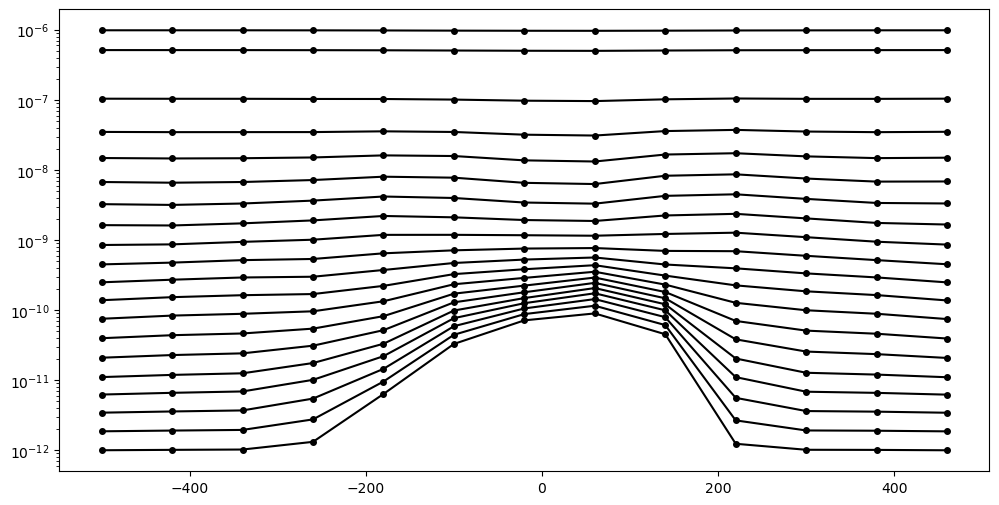

In [26]:
fig, ax = plt.subplots(1, 1, figsize=(12, 6))
ax.semilogy(rx_x, -dobs_reshaped[1, :, :], "-ok", ms=4);

In [27]:
relative_error = 0.05
noise_floor = 1e-12

In [28]:
len(rx_times)

20

In [ ]:
# last 5 channels; the parametric inversion is cleaner with fewer, later
# channels (more diffusion-smoothed -> naturally biased toward the smooth
# blob we want as a starting model).
times_invert = slice(15, None)
rx_times[times_invert]

In [30]:
source_list_invert = []

for i in range(rx_locs.shape[0]):
    rx = tdem.receivers.PointMagneticFluxTimeDerivative(rx_locs[i, :], rx_times[times_invert], orientation="z")
    src = tdem.sources.CircularLoop(
        receiver_list=[rx], location=rx_locs[i, :], orientation="z", radius=10,
        waveform=tdem.sources.StepOffWaveform()
    )
    source_list_invert.append(src)

survey_invert = tdem.Survey(source_list_invert)

In [31]:
dobs_invert = dobs.reshape(len(rx_y), len(rx_x), n_times_invert)[:, :, times_invert].flatten()
data_invert = Data(
    survey_invert, dobs=dobs_invert,
    standard_deviation=np.abs(dobs_invert)*relative_error + noise_floor
)

In [ ]:
param_mappings = []
param_sims = []

global_ellipsoid = ParametricEllipsoid(
    global_mesh,
    active_cells=active_cells_map.active_cells,
    boundary_sharpness=10.0,
    # slopeFact=10,
)

for ii, local_mesh in enumerate(mesh_list):

    tile_map = maps.TileMap(global_mesh, active_cells_map.active_cells, local_mesh)

    local_actmap = maps.InjectActiveCells(
        local_mesh,
        active_cells=tile_map.local_active,
        value_inactive=np.log(1e-8)
    )
    param_mappings.append(tile_map * global_ellipsoid)

    local_survey = tdem.Survey([survey_invert.source_list[ii]])
    param_sims.append(tdem.simulation.Simulation3DElectricField(
            mesh=local_mesh,
            survey=local_survey,
            time_steps=time_steps,
            solver=Solver,
            sigmaMap=maps.ExpMap(local_mesh) * local_actmap
        )
    )

sim_parametric = MultiprocessingMetaSimulation(param_sims, param_mappings)

In [ ]:
# Order: p_0, log_rx, log_ry, log_rz, phi_x, phi_y, phi_z, x_0, y_0, z_0, p_interior
# Vertical ellipsoid (rz > rx, ry) centered at the midpoint of the expected
# target depth range. Semi-axes (50, 50, 150) m; intentionally far from the
# true (dipping, oblate-ish) target orientation so the inversion is not
# initialized at the answer.
parametric_model = np.r_[
    np.log(sigma_back),                   # p_0
    np.log(50), np.log(50), np.log(150),  # log_rx, log_ry, log_rz
    0, 0, 0,                              # phi_x, phi_y, phi_z
    0, 0, -200,                           # x_0, y_0, z_0
    np.log(sigma_target),                 # p_interior
]


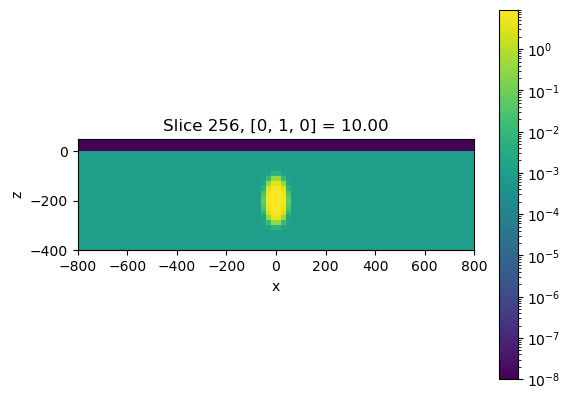

In [93]:
fig, ax = plt.subplots(1, 1)
plt.colorbar(
    mesh.plot_slice(
        maps.ExpMap()*active_cells_map*global_ellipsoid * parametric_model, normal="y", ax=ax,
        pcolor_opts={"norm":LogNorm()}
        )[0],
    ax=ax
)

ax.set_xlim(800*np.r_[-1, 1])
ax.set_ylim(np.r_[-400, 50])
ax.set_aspect(1)

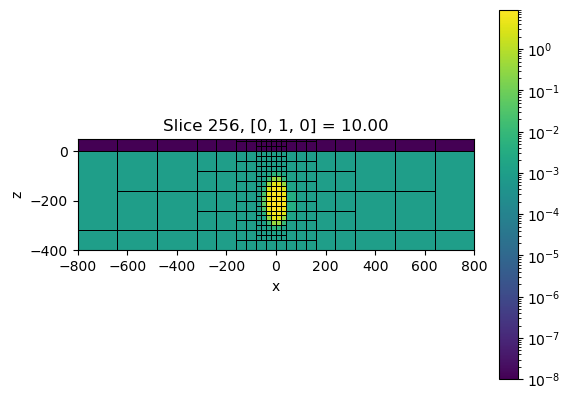

In [94]:
ind = 19
local_mesh = mesh_list[ind]
local_sim = param_sims[ind]
local_mapping = param_mappings[ind]

fig, ax = plt.subplots(1, 1)
plt.colorbar(local_mesh.plot_slice(
    local_sim.sigmaMap * local_mapping * parametric_model, normal="y", pcolor_opts={"norm":LogNorm()},
    ax=ax,
    # grid=True,
    grid_opts={"color":"k", "lw":0.5},
)[0], ax=ax)

ax.set_xlim(800*np.r_[-1, 1])
ax.set_ylim(np.r_[-400, 50])
ax.set_aspect(1)

In [95]:
dpred_parametric = sim_parametric.dpred(parametric_model)

In [96]:
n_times_invert = len(rx_times[times_invert])
dpred_parametric_reshaped = dpred_parametric.reshape(len(rx_y), len(rx_x), n_times_invert)

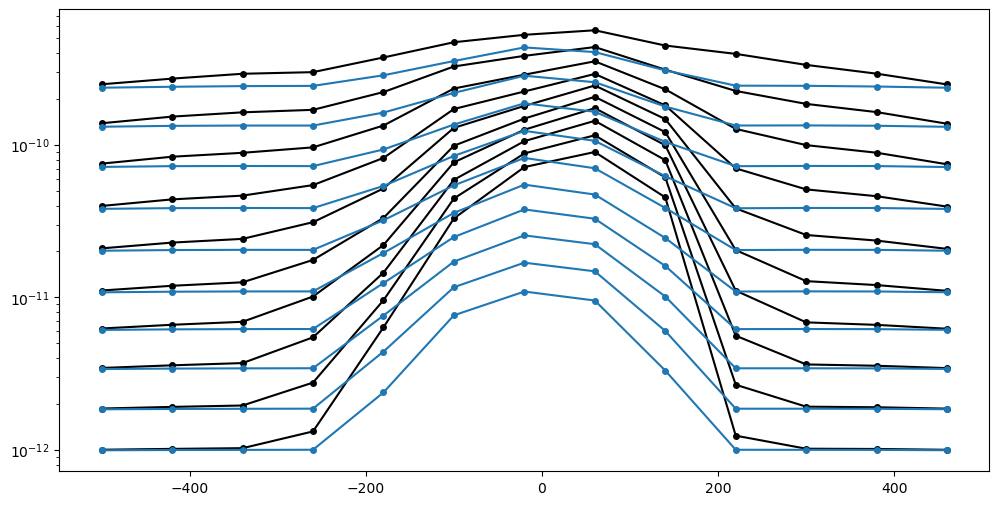

In [97]:
fig, ax = plt.subplots(1, 1, figsize=(12, 6))
ind = 1
ax.semilogy(rx_x, -dobs_reshaped[ind, :, times_invert], "-ok", ms=4);
ax.semilogy(rx_x, -dpred_parametric_reshaped[ind, :, :], "-oC0", ms=4);

In [ ]:
# Inflated above the 5% generation noise to account for model insufficiency
# (a single ellipsoid is an approximation to the dipping slab).
rel_err_parametric = 0.10
data_invert.standard_deviation = np.abs(dobs_invert)*rel_err_parametric + noise_floor
dmis = data_misfit.L2DataMisfit(simulation=sim_parametric, data=data_invert)
regmesh = discretize.TensorMesh([len(parametric_model)])
reg = regularization.Smallness(regmesh)


In [ ]:
# Order: p_0, log_rx, log_ry, log_rz, phi_x, phi_y, phi_z, x_0, y_0, z_0, p_interior
lower = np.r_[
    np.log(1e-6),                              # p_0
    np.log(5), np.log(5), np.log(5),           # semi-axes >= 5 m
    -np.pi, -np.pi, -np.pi,                    # angles
    -np.inf, -np.inf, -np.inf,                 # centers
    np.log(1e-3),                              # p_interior >= 1e-3 S/m
]
upper = np.r_[
    np.log(1e-1),                              # p_0 <= 0.1 S/m
    np.log(1000), np.log(1000), np.log(1000),  # semi-axes <= 1 km
    np.pi, np.pi, np.pi,
    np.inf, np.inf, 0.0,                       # z_0 <= 0 (underground)
    np.log(1e3),                               # p_interior <= 1000 S/m
]

opt = optimization.ProjectedGNCG(
    maxIter=10,
    lower=lower,
    upper=upper,
    cg_maxiter=15,
)
inv_prob = inverse_problem.BaseInvProblem(dmis, reg, opt, beta=0)


In [100]:
# Defining a starting value for the trade-off parameter (beta) between the data
# misfit and the regularization.
save_iteration = directives.SaveOutputDictEveryIteration(
    # saveOnDisk=True,
)
target_misfit = directives.TargetMisfit()

In [101]:
# The directives are defined as a list.
directives_list = [
    save_iteration,
    target_misfit,
]

# Here we combine the inverse problem and the set of directives
inv = inversion.BaseInversion(inv_prob, directives_list)

In [102]:
m0 = parametric_model.copy()

In [103]:
mopt_parametric = inv.run(m0)
# mopt_parametric = np.load("mopt_parametric.npy")

INFO: simpeg.InvProblem will set Regularization.reference_model to m0.
INFO: 
simpeg.InvProblem is setting bfgsH0 to the inverse of the reg.deriv2.
using the default solver Pardiso with the 'is_symmetric=True` option set.

INFO: Directive TargetMisfit: Target data misfit is 390.0



Running inversion with SimPEG v0.24.1.dev33+g42a5db944
================================================= Projected GNCG =================================================
  #     beta     phi_d     phi_m       f      |proj(x-g)-x|  LS   iter_CG   CG |Ax-b|/|b|  CG |Ax-b|   Comment   
-----------------------------------------------------------------------------------------------------------------
   0  0.00e+00  7.77e+03  0.00e+00  7.77e+03                         0           inf          inf                
   1  0.00e+00  4.39e+03  2.31e+02  4.39e+03    2.59e+04      1      10       1.45e-03     3.75e+01              
   2  0.00e+00  4.20e+03  1.91e+02  4.20e+03    1.06e+04      2      10       7.82e-04     8.31e+00              
   3  0.00e+00  2.63e+03  1.98e+02  2.63e+03    1.41e+04      2      10       2.14e-02     3.02e+02              
   4  0.00e+00  2.46e+03  1.95e+02  2.46e+03    1.38e+04      1      10       5.93e-02     8.16e+02              
   5  0.00e+00  1.97e+03  2.05e

In [104]:
mopt_parametric

array([  -6.86025884,    4.41029584,    3.92618437,    4.78813246,
         -0.71310342,    1.53677296,    0.68303599,   22.21224499,
          6.17783664, -179.40654611,    3.41242621])

In [105]:
# out = np.load("InversionModel_2026-06-11-08-40_04.npz", allow_pickle=True)["arr_0"].item()

In [106]:
# mopt_parametric = out["m"]

In [107]:
# out["dpred"]

In [108]:
dpred_reshaped = inv_prob.dpred.reshape(len(rx_y), len(rx_x), n_times_invert)
# dpred_reshaped = out["dpred"].reshape(len(rx_y), len(rx_x), n_times_invert)

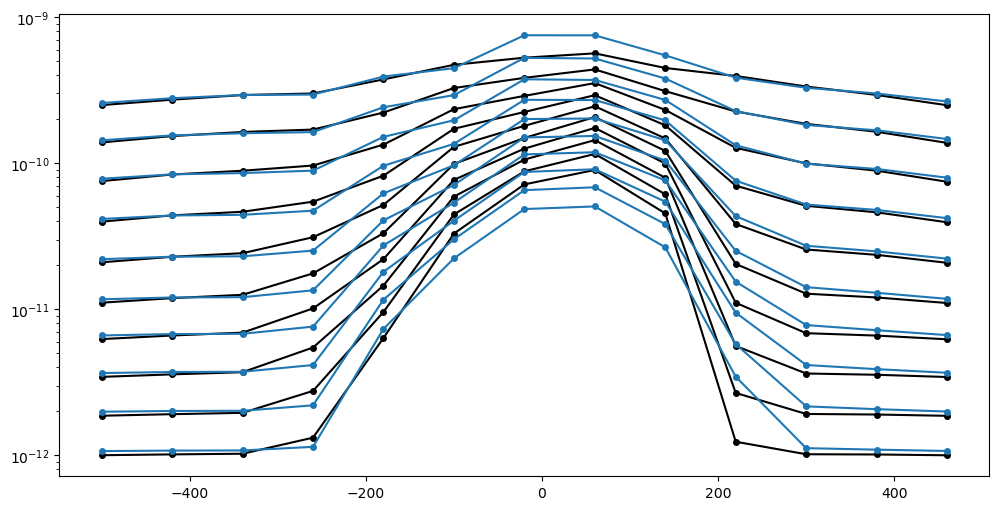

In [109]:
fig, ax = plt.subplots(1, 1, figsize=(12, 6))
ind = 1
ax.semilogy(rx_x, -dobs_reshaped[ind, :, -n_times_invert:], "-ok", ms=4);
ax.semilogy(rx_x, -dpred_reshaped[ind, :, :], "-oC0", ms=4);

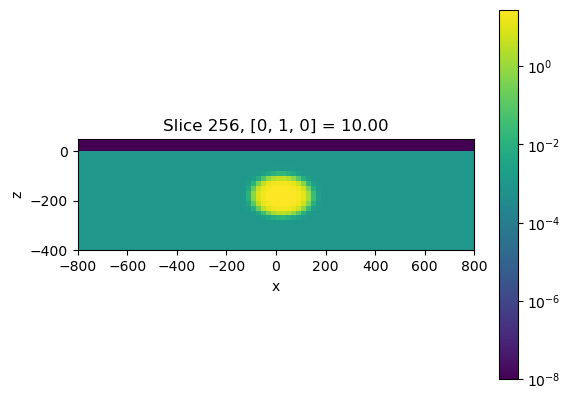

In [111]:
fig, ax = plt.subplots(1, 1)
plt.colorbar(
    mesh.plot_slice(
        maps.ExpMap()*active_cells_map*global_ellipsoid * save_iteration.outDict[10]["m"], normal="y", ax=ax,
        pcolor_opts={"norm":LogNorm()}
        )[0],
    ax=ax
)

ax.set_xlim(800*np.r_[-1, 1])
ax.set_ylim(np.r_[-400, 50])
ax.set_aspect(1)

In [60]:
data_invert_full = Data(
    survey, dobs=dobs,
    standard_deviation=np.abs(dobs)*relative_error + noise_floor
)

In [61]:
# set up an inversion now using the parametric as a reference model
dmis_full = data_misfit.L2DataMisfit(simulation=sim, data=data_invert_full)
reg = regularization.WeightedLeastSquares(
    global_mesh,
    active_cells = active_cells_map.active_cells,
    # reference_model = global_ellipsoid * mopt_parametric,
    reference_model = np.ones(active_cells_map.active_cells.sum()) * np.log(sigma_back),
    # alpha_s=1,
)


In [ ]:
# Bounds on log-conductivity: keeps the (lightly regularized) inversion from
# running off into unphysical conductivity values while it chases the fit.
n_active = active_cells_map.active_cells.sum()
lower = np.full(n_active, np.log(1e-6))
upper = np.full(n_active, np.log(1e2))

opt = optimization.ProjectedGNCG(
    maxIter=15,
    lower=lower,
    upper=upper,
    cg_maxiter=20,
)
inv_prob = inverse_problem.BaseInvProblem(dmis_full, reg, opt)


In [ ]:
# beta0_ratio = 1 -> data term ~ 30x reg term at m0, so the parametric
# structure in m0 is NOT wiped out in the first step. Cooling 2x per
# iteration lets the data take over progressively; target_misfit stops
# the run before beta gets unrealistically small.
starting_beta = directives.BetaEstimate_ByEig(beta0_ratio=1, n_pw_iter=2)
cool_beta = directives.BetaSchedule(coolingFactor=2, coolingRate=1)
save_iteration = directives.SaveOutputDictEveryIteration(
    # saveOnDisk=True,
)
target_misfit = directives.TargetMisfit()


In [75]:
# The directives are defined as a list.
directives_list = [
    starting_beta,
    cool_beta,
    save_iteration,
    target_misfit,
]

# Here we combine the inverse problem and the set of directives
inv = inversion.BaseInversion(inv_prob, directives_list)

The callback on the InexactGaussNewton minimizer was replaced.


In [76]:
# m0 = np.ones(active_cells_map.active_cells.sum()) * np.log(sigma_back)
m0 = global_ellipsoid * mopt_parametric

In [77]:
mrec = inv.run(m0)
# mrec = np.load("mrec_full.npy")

INFO: 
simpeg.InvProblem is setting bfgsH0 to the inverse of the reg.deriv2.
using the default solver Pardiso with the 'is_symmetric=True` option set.




Running inversion with SimPEG v0.24.1.dev33+g42a5db944


INFO: Directive TargetMisfit: Target data misfit is 780.0


============================ Inexact Gauss Newton ============================
  #     beta     phi_d     phi_m       f      |proj(x-g)-x|  LS    Comment   
-----------------------------------------------------------------------------
   0  6.14e-08  1.12e+04  1.07e+10  1.19e+04                      Skip BFGS  
   1  6.14e-08  1.03e+03  1.07e+10  1.69e+03    1.38e+03      0   Skip BFGS  
   2  3.07e-08  7.26e+02  1.07e+10  1.05e+03    3.39e+02      0   Skip BFGS  
------------------------- STOP! -------------------------
1 : |fc-fOld| = 3.0441e+02 <= tolF*(1+|f0|) = 1.1880e+03
1 : |xc-x_last| = 1.5906e+01 <= tolX*(1+|x0|) = 1.3876e+02
0 : |proj(x-g)-x|    = 3.3928e+02 <= tolG          = 1.0000e-01
0 : |proj(x-g)-x|    = 3.3928e+02 <= 1e3*eps       = 1.0000e-02
0 : maxIter   =       4    <= iter          =      2
------------------------- DONE! -------------------------


In [78]:
# out = np.load("InversionModel_2026-06-11-10-13_01.npz", allow_pickle=True)["arr_0"].item()
# mrec = out["m"]

In [79]:
save_iteration.outDict[2]["m"]

array([-6.76784947, -6.76784947, -6.76784947, ..., -6.76784947,
       -6.76784947, -6.76784947])

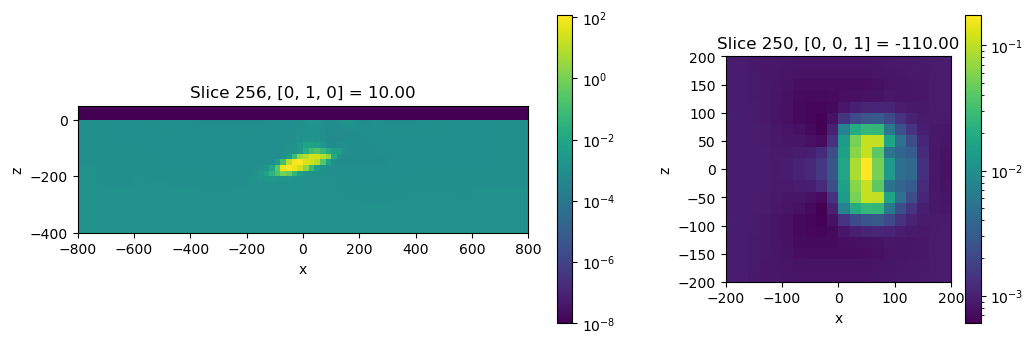

In [80]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4), gridspec_kw={"width_ratios":[2,1]})
iteration = 2
plt.colorbar(
    mesh.plot_slice(
        maps.ExpMap()*active_cells_map*save_iteration.outDict[iteration]["m"], normal="y", ax=ax[0],
        pcolor_opts={"norm":LogNorm()}
        )[0],
    ax=ax[0]
)

plt.colorbar(
    mesh.plot_slice(
        maps.ExpMap()*active_cells_map*save_iteration.outDict[iteration]["m"], normal="z", ax=ax[1],
        pcolor_opts={"norm":LogNorm()},
        ind=250,
        )[0],
    ax=ax[1]
)

ax[0].set_xlim(800*np.r_[-1, 1])
ax[0].set_ylim(np.r_[-400, 50])

ax[1].set_xlim(200*np.r_[-1, 1])
ax[1].set_ylim(200*np.r_[-1, 1])

for a in ax.flatten():
    a.set_aspect(1)

In [81]:
dpred_reshaped = save_iteration.outDict[iteration]["dpred"].reshape(len(rx_y), len(rx_x), -1)

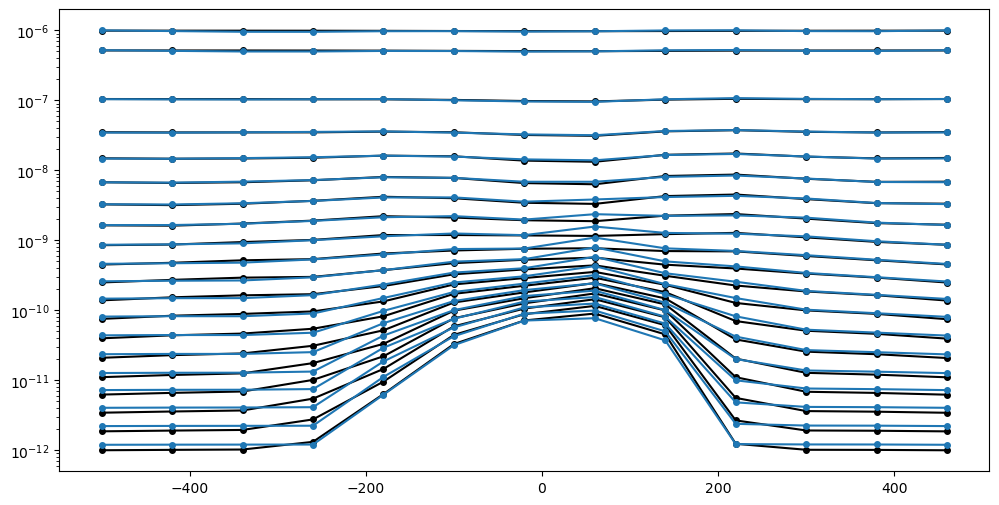

In [82]:
fig, ax = plt.subplots(1, 1, figsize=(12, 6))
ind = 1
ax.semilogy(rx_x, -dobs_reshaped[ind, :, :], "-ok", ms=4);
ax.semilogy(rx_x, -dpred_reshaped[ind, :, :], "-oC0", ms=4);